In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
#create an array
arr = np.arange(1_000_000)
#Compare loop vs vectorized execution
%timeit result = arr**2

%timeit result = [x**2 for x in arr]


667 μs ± 26.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
43.3 ms ± 297 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
# load data
import pathlib
base = pathlib.Path.cwd() 
data_path = base.parents[0]/'data/raw/starter_data.csv'
data= pd.read_csv(data_path)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  10 non-null     object
 1   value     10 non-null     int64 
 2   date      10 non-null     object
dtypes: int64(1), object(2)
memory usage: 372.0+ bytes


In [10]:
data.head()

,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05


In [11]:
data["value"].describe()

count    10.000000
mean     17.600000
std       7.381659
min      10.000000
25%      12.250000
50%      14.500000
75%      23.250000
max      30.000000
Name: value, dtype: float64

In [7]:
summary = data.groupby('category')["value"].agg(["count","mean","min","max"]).reset_index()
path = base.parents[0]/'data/processed/summary.csv'
summary.to_csv(path, index=False)
summary

,category,count,mean,min,max
0,A,4,11.500000,10,13
1,B,3,15.666667,14,18
2,C,3,27.666667,25,30


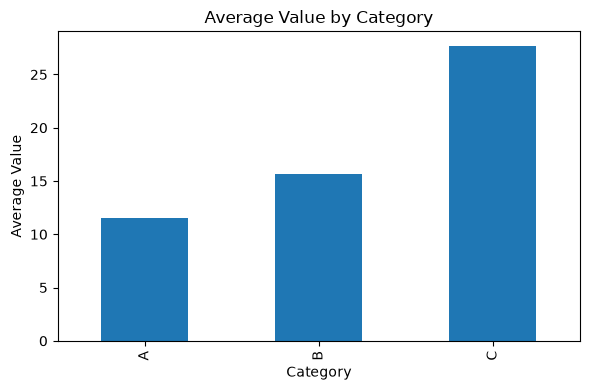

In [10]:
#plot: mean groupby category
import matplotlib.pyplot as plt
category_mean = data.groupby("category")["value"].mean()

plt.figure(figsize=(6, 4))
category_mean.plot(kind="bar")
plt.xlabel("Category")
plt.ylabel("Average Value")
plt.title("Average Value by Category")
plt.tight_layout()

path = base.parents[0]/'reports/average value by category.png'
plt.savefig(path)
plt.show()

In [ ]:
#check utils.py
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))


from src.utils import get_summary_stats

get_summary_stats(data["value"])

mean: 17.6, std: 7.381658952355418


(np.float64(17.6), np.float64(7.381658952355418))